#**Microproyecto 2**
## **Alcanzando los objetivos de desarrollo sostenible. Un aporte desde el machine learning**

Materia: Machine learning no supervisado

Profesora: Haydemar María Nuñez Castro

Estudiantes: Alberto Jose Zapata García, Sebastián Tapias Gómez
<br> <br>

Los objetivos de desarrollo sostenible (ODS), adoptados en 2015 como parte de la agenda de las naciones unidas para el desarrollo sostenible, constituyen un marco global compuesto por 16 objetivos orientados a abordar desafíos sociales, económicos y ambientales a escala mundial. Estos objetivos abarcan temáticas como la reducción de la pobreza, la educación de calidad, la acción climática y el desarrollo sostenible de las ciudades, entre otros. En un contexto donde la producción de información textual como informes, noticias, artículos académicos o documentos institucionales crece constantemente, surge la necesidad de contar con herramientas que permitan identificar y clasificar automáticamente el contenido según los objetivos a los que se relaciona.

Este proyecto aborda la clasificación automática de textos según los objetivos de desarrollo sostenible mediante técnicas de machine learning aplicadas al procesamiento de lenguaje natural. El objetivo principal es desarrollar un modelo capaz de asignar un texto al objetivo de desarrollo sostenible más relacionado con su temática. Para ello, los textos son transformados en representaciones numéricas que permiten capturar patrones relevantes, los cuales son posteriormente utilizados por algoritmos de clasificación para aprender las características distintivas de cada categoría. Este enfoque facilita el análisis sistemático de grandes volúmenes de información y puede resultar útil en contextos como el monitoreo de políticas públicas, el análisis de publicaciones institucionales o la evaluación del impacto social de proyectos y organizaciones.

Importamos las librerías necesarias

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
from nltk.stem import SnowballStemmer
from nltk.tokenize import word_tokenize
from nltk import RegexpTokenizer
from nltk.corpus import stopwords

from wordcloud import WordCloud

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, precision_score, recall_score

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\User\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
import warnings
warnings.filterwarnings('ignore')

# Carga y procesamiento de datos

Importamos los datos correspondientes a textos relacionados con alguno de los objetivos de desarrollo sostenible (ODS)

In [3]:
data_raw = pd.read_excel('Train_textosODS.xlsx')

Hacemos la división de los datos para entrenamiento y para prueba. Se utilizó el parámetro stratify, lo cual garantiza que la proporción de las clases (ODS) se mantenga similar en ambos conjuntos, permitiendo que la representación de clases sea congruente y no se puedan generar sesgos asociados a las muestras

In [4]:
train, test = train_test_split(data_raw,
                               random_state=77,
                               test_size=0.2,
                               stratify=data_raw['ODS'])

Verificamos si hay datos duplicados o nulos en los conjuntos de entrenamiento y de prueba

In [5]:
print(f'Número de datos duplicados para entrenamiento: {train.duplicated().sum()}')
print(f'Número de datos duplicados para prueba: {test.duplicated().sum()}')

print(f'Número de datos nulos para entrenamiento:\n{train.isna().sum()}')
print(f'Número de datos nulos para prueba:\n{test.isna().sum()}')

Número de datos duplicados para entrenamiento: 0
Número de datos duplicados para prueba: 0
Número de datos nulos para entrenamiento:
textos    0
ODS       0
dtype: int64
Número de datos nulos para prueba:
textos    0
ODS       0
dtype: int64


Separamos los textos de las etiquetas

In [6]:
x_train = train['textos']
y_train = train['ODS']

x_test = test['textos']
y_test = test['ODS']

Como parte del preprocesamiento del texto, todos los documentos fueron convertidos a minúsculas. Este paso permite evitar que el modelo trate palabras iguales como términos diferentes debido únicamente a diferencias en mayúsculas o minúsculas. Por ejemplo, las palabras “Educación” y “educación” representan el mismo concepto, por lo que deben tratarse como un mismo término dentro del modelo

In [7]:
lowercased = x_train.apply(lambda x: x.lower())

### Tokenización

Separamos cada uno de los textos del conjunto de datos por palabras/símbolos para posteriormente hacer la bolsa de palabras y vemos uno de los textos resultantes con la tokenización aplicada

In [8]:
tokenized = lowercased.apply(lambda x: word_tokenize(x))
tokenized[0]

['``',
 'aprendizaje',
 "''",
 'y',
 '``',
 'educación',
 "''",
 'se',
 'consideran',
 'sinónimos',
 'de',
 'escolarización',
 'formal',
 '.',
 'las',
 'organizaciones',
 'auxiliares',
 ',',
 'como',
 'las',
 'editoriales',
 'de',
 'educación',
 ',',
 'las',
 'juntas',
 'examinadoras',
 'y',
 'las',
 'organizaciones',
 'de',
 'formación',
 'de',
 'docentes',
 ',',
 'se',
 'consideran',
 'extensiones',
 'de',
 'los',
 'acuerdos',
 'establecidos',
 'por',
 'los',
 'gobiernos',
 '.',
 'este',
 'marco',
 'de',
 'comprensión',
 'se',
 'ha',
 'vuelto',
 'cada',
 'vez',
 'más',
 'inadecuado',
 '.']

Podemos usar una técnica de tokenización diferente para eliminar los signos de puntuación y símbolos especiales del texto. Estos elementos generalmente no aportan información relevante para la tarea de clasificación y pueden introducir ruido en el modelo. Por esta razón, se utiliza un tokenizador basado en expresiones regulares que permite conservar únicamente palabras. Aplicamos esta tokenización y vemos uno de los textos resultantes

In [9]:
tokenizer = RegexpTokenizer(r'\w+')
tokenized_no_punct = lowercased.apply(
    lambda x: tokenizer.tokenize(x))
tokenized_no_punct[0]

['aprendizaje',
 'y',
 'educación',
 'se',
 'consideran',
 'sinónimos',
 'de',
 'escolarización',
 'formal',
 'las',
 'organizaciones',
 'auxiliares',
 'como',
 'las',
 'editoriales',
 'de',
 'educación',
 'las',
 'juntas',
 'examinadoras',
 'y',
 'las',
 'organizaciones',
 'de',
 'formación',
 'de',
 'docentes',
 'se',
 'consideran',
 'extensiones',
 'de',
 'los',
 'acuerdos',
 'establecidos',
 'por',
 'los',
 'gobiernos',
 'este',
 'marco',
 'de',
 'comprensión',
 'se',
 'ha',
 'vuelto',
 'cada',
 'vez',
 'más',
 'inadecuado']

### Eliminación de palabras vacías

Ahora tomamos la lista de palabras vacías del español de la librería nltk para eliminarlas de cada texto debido a que son palabras que están en la mayoría de textos y no aportan ninguna clase de contenido en términos de información, y vemos uno de los textos resultantes con esta eliminación

In [10]:
nltk_stopwords = stopwords.words("spanish")
no_stopwords = tokenized_no_punct.apply(lambda x: [token for token in x if token not in nltk_stopwords])
no_stopwords[0]

['aprendizaje',
 'educación',
 'consideran',
 'sinónimos',
 'escolarización',
 'formal',
 'organizaciones',
 'auxiliares',
 'editoriales',
 'educación',
 'juntas',
 'examinadoras',
 'organizaciones',
 'formación',
 'docentes',
 'consideran',
 'extensiones',
 'acuerdos',
 'establecidos',
 'gobiernos',
 'marco',
 'comprensión',
 'vuelto',
 'cada',
 'vez',
 'inadecuado']

Vamos a generar una nube de palabras para ver las palabras más frecuentes. Generamos un string con los textos concatenados

In [11]:
wc_text = ' '.join(word for text in no_stopwords for word in text)

Ahora generamos la imagen

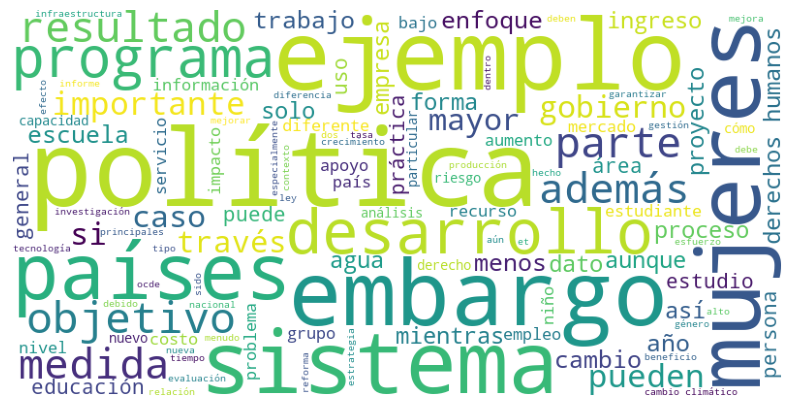

In [12]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color ='white',
    min_font_size=10,
    max_font_size=110
).generate(wc_text)
plt.figure(figsize=(10, 10))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

### Stemming

Ahora reducimos cada token a una forma más general para que palabras con significados similares, pero que difieren en su escritura puedan representarse como un solo término. Usamos una clase de Stemming en específico para palabras en español y vemos uno de los textos con el stemming aplicado

In [13]:
stemmer = SnowballStemmer('spanish')
stemmed = no_stopwords.apply(lambda x: [stemmer.stem(token) for token in x])
stemmed[0]

['aprendizaj',
 'educ',
 'consider',
 'sinon',
 'escolariz',
 'formal',
 'organiz',
 'auxiliar',
 'editorial',
 'educ',
 'junt',
 'examin',
 'organiz',
 'formacion',
 'docent',
 'consider',
 'extension',
 'acuerd',
 'establec',
 'gobi',
 'marc',
 'comprension',
 'vuelt',
 'cad',
 'vez',
 'inadecu']

# Definición de pasos del pipeline y grilla de búsqueda

### Procesamiento de textos

Creamos la función text_preprocess para hacer el procesamiento de cada uno de los textos a utilizar en el entrenamiento y posterior validación de los modelos. Esta función incluye llevar cada palabra a minúsculas, tokenizar los textos para quedarnos solo con las palabras, eliminar las palabras vacías que no aportan información, y aplicar la función de stemming para "unificar" términos similares que difieren en su escritura

In [14]:
def text_preprocess(text):
    tokenizer = RegexpTokenizer(r'\w+')
    stemmer = SnowballStemmer('spanish')

    tokens = tokenizer.tokenize(text.lower())
    tokens = [word for word in tokens if word not in nltk_stopwords]
    tokens = [stemmer.stem(word) for word in tokens]
    return ' '.join(tokens)

Para convertir los textos en una representación numérica adecuada para los modelos de aprendizaje automático se utilizó TF-IDF mediante la clase TfidfVectorizer. Esta técnica transforma cada documento en un vector numérico donde cada dimensión corresponde a un término del vocabulario. El valor asociado a cada término refleja su importancia dentro del documento. De esta forma, las palabras que aparecen con frecuencia en un documento pero que no son comunes en todos los textos reciben un mayor peso, lo que permite diferenciar de mejor manera las palabras específicas que son útiles para diferenciar los textos. Adicionalmente, pasamos la función text_preprocess para que se ejecuten todos los pasos de preprocesamiento antes de construir la bolsa de palabras

In [15]:
vectorizer = TfidfVectorizer(preprocessor=text_preprocess)

### Reducción de la dimensionalidad

Para este paso decidimos usar la función de TruncatedSVD para poder hacer la reducción de la dimensionalidad y usamos el número de componentes recomendado por la librería para análisis de textos

In [16]:
tsvd = TruncatedSVD(n_components=100, random_state=32)

### Creación de los pipelines para el entrenamiento

Para el entrenamiento de los modelos se utilizaron pipelines, los cuales permiten encadenar diferentes etapas de procesamiento y modelado dentro de una única estructura. Esto facilita la reproducibilidad del procedimiento y garantiza que las mismas transformaciones se apliquen tanto en los datos de entrenamiento como en los de prueba.
En este caso, cada pipeline incluye tres etapas principales:


*   Vectorización del texto, que convierte los documentos en representaciones numéricas.
*   Reducción de dimensionalidad mediante TruncatedSVD, que permite proyectar los vectores en un espacio de menor dimensión conservando la mayor parte de la información relevante.
*   Entrenamiento del modelo de clasificación, utilizando dos algoritmos diferentes para comparar su desempeño: LinearSVC y LogisticRegression

Para la tarea de clasificación de textos se utilizaron LinearSVC y Logistic Regression, dos modelos lineales ampliamente empleados en problemas de procesamiento de lenguaje natural. Estos modelos son particularmente adecuados para trabajar con representaciones de texto basadas en TF-IDF, donde los documentos se representan como vectores de alta dimensionalidad y con muchas características dispersas.
LinearSVC busca encontrar el hiperplano que maximiza el margen entre las clases, lo que suele ofrecer buen desempeño en tareas de clasificación de texto. Por su parte, Logistic Regression es un modelo probabilístico ampliamente utilizado como referencia en problemas de clasificación debido a su estabilidad y facilidad de interpretación.
La comparación entre ambos modelos permite evaluar cuál de estos enfoques lineales ofrece mejor desempeño para la clasificación de textos del conjunto de datos utilizado


In [17]:
pipeline_svc = Pipeline([
    ("vectorizer", vectorizer),
    ("dimred", tsvd),
    ("model", LinearSVC())
])

pipeline_logreg = Pipeline([
    ("vectorizer", vectorizer),
    ("dimred", tsvd),
    ("model", LogisticRegression())
])

Aquí definimos los parámetros de búsqueda que se aplicarán en los modelos. Decidimos variar los parámetros de regularización en ambos modelos, el solver en el modelo de regresión logística y la función de pérdida en el modelo de clasificador de vectores de soporte

In [18]:
param_grid_svc = {
    "model__C": [0.1, 1, 10],
    "model__loss": ['hinge', 'squared_hinge']
}

param_grid_logreg = {
    "model__C": [0.1, 1, 10],
    "model__solver": ['lbfgs', 'newton-cg']
}

Para optimizar el desempeño de los modelos se realizó una búsqueda de hiperparámetros utilizando GridSearchCV con validación cruzada de 5 particiones. Este proceso permite evaluar diferentes combinaciones de hiperparámetros y quedarnos con aquellos que ofrecen el mejor desempeño promedio. Decidimos quedarnos con las métricas de accuracy, precision y recall, siendo la principal por la cual guiarnos la métrica de accuracy debido a que en el contexto de este microproyecto no es tan relevante disminuir falsos positivos o falsos negativos, sino maximizar la cantidad de clasificaciones correctas en general. Por esto, nos quedaremos con los modelos que presenten el mejor accuracy, y usaremos las métricas de precision y recall como apoyo en caso de que el accuracy no sea suficiente para determinar el mejor modelo

In [19]:
grid_svc = GridSearchCV(
    pipeline_svc,
    param_grid_svc,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision_macro",
        "recall": "recall_macro"
    },
    refit="accuracy",
    n_jobs=-1,
    verbose=2
)

grid_logreg = GridSearchCV(
    pipeline_logreg,
    param_grid_logreg,
    cv=5,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision_macro",
        "recall": "recall_macro"
    },
    refit="accuracy",
    n_jobs=-1,
    verbose=2
)

# Entrenamiento de modelos de clasificación

Entrenamos los modelos de SVC

In [20]:
grid_svc.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vectorizer',
                                        TfidfVectorizer(preprocessor=<function text_preprocess at 0x00000135A66AB880>)),
                                       ('dimred',
                                        TruncatedSVD(n_components=100,
                                                     random_state=32)),
                                       ('model', LinearSVC())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__loss': ['hinge', 'squared_hinge']},
             refit='accuracy',
             scoring={'accuracy': 'accuracy', 'precision': 'precision_macro',
                      'recall': 'recall_macro'},
             verbose=2)

Entrenamos los modelos de regresión logística

In [21]:
grid_logreg.fit(x_train, y_train)

Fitting 5 folds for each of 6 candidates, totalling 30 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('vectorizer',
                                        TfidfVectorizer(preprocessor=<function text_preprocess at 0x00000135A66AB880>)),
                                       ('dimred',
                                        TruncatedSVD(n_components=100,
                                                     random_state=32)),
                                       ('model', LogisticRegression())]),
             n_jobs=-1,
             param_grid={'model__C': [0.1, 1, 10],
                         'model__solver': ['lbfgs', 'newton-cg']},
             refit='accuracy',
             scoring={'accuracy': 'accuracy', 'precision': 'precision_macro',
                      'recall': 'recall_macro'},
             verbose=2)

# Evaluación de modelos

Miramos los mejores hiperparámetros encontrados de cada uno de los modelos

In [22]:
print("Los mejores parámetros del modelo SVC son:\n", grid_svc.best_params_, "\n")
print("Los mejores parámetros del modelo de regresión lógistica son:\n", grid_logreg.best_params_)

Los mejores parámetros del modelo SVC son:
 {'model__C': 1, 'model__loss': 'squared_hinge'} 

Los mejores parámetros del modelo de regresión lógistica son:
 {'model__C': 10, 'model__solver': 'newton-cg'}


Miramos el mejor accuracy correspondiente al modelo con los hiperparámetros anteriores

In [23]:
print(f"El accuracy obtenido por el mejor modelo SVC fue: {round(grid_svc.best_score_, 4)*100}%")
print(f"El accuracy obtenido por el mejor modelo de regresión lógistica fue: {round(grid_logreg.best_score_, 4)*100}%")

El accuracy obtenido por el mejor modelo SVC fue: 85.82%
El accuracy obtenido por el mejor modelo de regresión lógistica fue: 85.64%


Después del proceso de entrenamiento y validación cruzada, comparamos los modelos LinearSVC y Logistic Regression utilizando las métricas de accuracy, precision y recall. Los resultados muestran que ambos modelos presentan un desempeño muy similar en las tres métricas evaluadas. Aunque LinearSVC obtiene un valor ligeramente mayor en accuracy y precision, la diferencia con regresión logística es mínima y no representa una mejora significativa en el desempeño general del modelo. Por otra parte, la regresión logística presenta un valor ligeramente superior en recall, pero tampoco llega a ser lo suficientemente mejor como para representar un aumento importante.

In [24]:
results_svc = pd.DataFrame(grid_svc.cv_results_)
results_logreg = pd.DataFrame(grid_logreg.cv_results_)

svc_best = results_svc.loc[grid_svc.best_index_]
logreg_best = results_logreg.loc[grid_logreg.best_index_]

metrics_table = pd.DataFrame({
    "Model": ["SVC", "Logistic Regression"],
    "Accuracy": [svc_best["mean_test_accuracy"], logreg_best["mean_test_accuracy"]],
    "Precision": [svc_best["mean_test_precision"], logreg_best["mean_test_precision"]],
    "Recall": [svc_best["mean_test_recall"], logreg_best["mean_test_recall"]],
})

print(metrics_table)

                 Model  Accuracy  Precision    Recall
0                  SVC  0.858233   0.838233  0.822223
1  Logistic Regression  0.856421   0.836234  0.822686


Dado que el desempeño de ambos modelos es prácticamente equivalente, se decidió seleccionar el mejor modelo de regresión logística como modelo final, debido a que este modelo ofrece mayor interpretabilidad y estabilidad en la estimación de probabilidades, lo cual puede ser útil para analizar la contribución de las características en el proceso de clasificación, incluso después de la aplicación de la reducción de dimensionalidad, cosa que con SVC sería mucho más complejo

In [25]:
best_model_logreg = grid_logreg.best_estimator_

Hacemos la clasificación de los datos de prueba y guardamos las etiquetas resultantes

In [26]:
y_pred = best_model_logreg.predict(x_test)

Calculamos el accuracy, precision y recall resultante

In [27]:
score_test = round(accuracy_score(y_test, y_pred), 4)*100
precision_test = round(precision_score(y_test, y_pred, average="macro"), 4)*100
recall_test = round(recall_score(y_test, y_pred, average="macro"), 4)*100

print(f"El accuracy obtenido en los datos de prueba fue de: {score_test}%")
print(f"El precision promedio obtenido en los datos de prueba fue de: {precision_test}%")
print(f"El recall promedio obtenido en los datos de prueba fue de: {recall_test}%")

El accuracy obtenido en los datos de prueba fue de: 86.59%
El precision promedio obtenido en los datos de prueba fue de: 84.91%
El recall promedio obtenido en los datos de prueba fue de: 83.56%


Calculamos el precision, recall y f1 respecto a cada una de las clases del conjunto de datos de prueba

In [28]:
ods_nombres = [
    "ODS 1: Fin de la pobreza",
    "ODS 2: Hambre cero",
    "ODS 3: Salud y bienestar",
    "ODS 4: Educación de calidad",
    "ODS 5: Igualdad de género",
    "ODS 6: Agua limpia y saneamiento",
    "ODS 7: Energía asequible y no contaminante",
    "ODS 8: Trabajo decente y crecimiento económico",
    "ODS 9: Industria, innovación e infraestructura",
    "ODS 10: Reducción de las desigualdades",
    "ODS 11: Ciudades y comunidades sostenibles",
    "ODS 12: Producción y consumo responsables",
    "ODS 13: Acción por el clima",
    "ODS 14: Vida submarina",
    "ODS 15: Vida de ecosistemas terrestres",
    "ODS 16: Paz, justicia e instituciones sólidas"
]

In [29]:
print(classification_report(
    y_test,
    y_pred,
    target_names=ods_nombres
))

                                                precision    recall  f1-score   support

                      ODS 1: Fin de la pobreza       0.80      0.79      0.80       101
                            ODS 2: Hambre cero       0.86      0.82      0.84        74
                      ODS 3: Salud y bienestar       0.87      0.94      0.90       179
                   ODS 4: Educación de calidad       0.92      0.95      0.94       205
                     ODS 5: Igualdad de género       0.88      0.93      0.90       214
              ODS 6: Agua limpia y saneamiento       0.90      0.88      0.89       139
    ODS 7: Energía asequible y no contaminante       0.89      0.84      0.87       158
ODS 8: Trabajo decente y crecimiento económico       0.66      0.66      0.66        89
ODS 9: Industria, innovación e infraestructura       0.77      0.72      0.75        69
        ODS 10: Reducción de las desigualdades       0.73      0.59      0.65        70
    ODS 11: Ciudades y comunida

Como podemos observar, las métricas de clasificación para cada una de las clases suele acercarce a un 80%, lo cual indica un buen ajuste. Algunas clases superan el 90% y otras se encuentran por debajo del 80%, pero la norma general es que se mantengan entre esos dos valores. Podemos decir que el modelo mostró buenos resultados

In [35]:
#Se generan 5 pruebas sobre los textos para validar la precision del modelo
for i in range(5):
    print("Texto:")
    print(x_test.iloc[i])
    print("ODS real:", ods_nombres[y_test.iloc[i]-1])
    print("Predicción del modelo:", ods_nombres[y_pred[i]-1])
    print("-------------")

Texto:
Dentro de esta área, los socios para el desarrollo están trabajando en tres niveles (Kindornay y Reilly-King, 2013, Di Bella et al., En el nivel macro, los programas de los socios para el desarrollo fortalecen el entorno propicio o el clima de inversión (es decir, el desarrollo de políticas, regulaciones e instituciones). marcos) que apoya la ecologización del sector privado y la inversión verde, apoyando el diseño de políticas y construyendo la capacidad en el país de las agencias gubernamentales y otras partes interesadas e instituciones involucradas. Esta es un área importante de apoyo, ya que la efectividad del proyecto Las intervenciones de financiación del desarrollo a nivel nacional, para movilizar la inversión privada a lo largo del tiempo y garantizar la obtención de los resultados ambientales y sociales previstos, dependen en gran medida del marco de políticas adecuado que se establezca en los países en desarrollo. , y también contar con ciertos elementos adicionales p

# Conclusión

El desarrollo de este microproyecto permitió recorrer todo el proceso necesario para construir un sistema de clasificación automática de textos según los objetivos de desarrollo sostenible. Desde la preparación y limpieza del texto, pasando por la transformación de los documentos en representaciones numéricas, hasta la comparación formal de diferentes modelos de clasificación y la validación mediante métricas de desempeño, cada etapa permitió justificar de manera estructurada las decisiones tomadas.
La fase de preprocesamiento fue especialmente importante. Normalizar el texto, eliminar signos de puntuación y stopwords, y aplicar stemming permitió reducir el ruido presente en los documentos y concentrar la información en los términos realmente relevantes. Posteriormente, la representación mediante TF-IDF permitió transformar los textos en vectores numéricos que reflejan la importancia relativa de cada término dentro del conjunto de documentos. Para mejorar la eficiencia del modelo y capturar relaciones latentes entre palabras, se aplicó reducción de dimensionalidad mediante TruncatedSVD, lo cual facilitó el entrenamiento de los modelos de clasificación.
En cuanto a la comparación entre LinearSVC y Logistic Regression, ambos modelos mostraron un desempeño muy similar en términos de accuracy, precision y recall. Sin embargo, Logistic Regression presentó resultados comparables que facilita la interpretación del modelo y la estimación de probabilidades de pertenencia a cada clase. Debido a esto decidimos seleccionar este modelo como la opción final para la tarea de clasificación.
En conjunto, el proyecto demostró que la clasificación automática de textos puede abordarse de manera rigurosa mediante técnicas de procesamiento de lenguaje natural y modelos de aprendizaje supervisado y no supervisado por la reducción de la dimensionalidad aplicada, siempre que exista un proceso estructurado de preparación de datos, selección de modelos y evaluación mediante métricas adecuadas.


In [40]:
import joblib

joblib.dump(best_model_logreg, "modelo_ods.joblib")

['modelo_ods.joblib']